# Additional Exploratory Data Analysis

## Research Question

For San Francisco from 2023 to 2025, did Waymo's driverless ride-hailing expansion correspond with changes in transportation activity after considering broader transportation trends, seasonality, and general travel demand?

## Goal of this notebook

This notebook extends the first exploratory data analysis by focusing on the main methodological concerns raised in the project feedback.

Instead of repeating the first notebook's general trend plots and correlation analysis, this notebook uses a smaller set of targeted EDA techniques to examine possible confounding factors.

The analyses included in this notebook are:

1. Event-window comparisons around Waymo expansion dates
2. Rolling averages to smooth monthly variation
3. Seasonality checks by calendar month
4. Demand-adjusted Waymo activity measures
5. Exploratory Regression Check With Controls

These analyses help clarify whether Waymo's growth appears separate from other transportation trends or whether it occurred alongside broader changes in San Francisco transportation activity.

The dataset analyzed in this notebook is:

`data/02-processed/final_transportation_monthly.csv`

## Key Waymo Expansion Dates Used in This Analysis

- **August 2023** — Waymo launches commercial driverless service to the general public in San Francisco.
- **June 2024** — Waymo One expands service availability to all riders in San Francisco.

LLMs were used in creation of this notebook.

# Import Packages

The following packages are used for data manipulation, visualization, and exploratory data analysis.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)

# Load Dataset

The final cleaned monthly transportation dataset is loaded for additional exploratory analysis.

In [2]:
df = pd.read_csv(
    "data/02-processed/final_transportation_monthly.csv"
)

df.head()

,month,waymo_passenger_miles,taxi_trips,taxi_total_fare,taxi_avg_fare,muni_monthly_boardings,muni_recovery_rate,sfo_ground_trips,post_waymo_public_launch,post_waymo_open_to_all,time_trend,waymo_pct_change,taxi_pct_change,muni_pct_change,log_waymo_passenger_miles,log_taxi_trips,log_muni_monthly_boardings
0,2023-01,30308.620,212798.0,6636580.34,31.187231,10662000.0,0.629412,754556.0,0,0,0,NaN,NaN,NaN,10.319220,12.268103,16.182197
1,2023-02,20492.771,189659.0,5741866.64,30.274686,10645000.0,0.662500,694951.0,0,0,1,-32.386328,-10.873692,-0.159445,9.927876,12.152988,16.180601
2,2023-03,22891.252,208091.0,6407863.35,30.793563,11854000.0,0.676136,864610.0,0,0,2,11.704035,9.718495,11.357445,10.038554,12.245736,16.288176
3,2023-04,25934.950,218564.0,6557043.88,30.000567,12189000.0,0.681564,847180.0,0,0,3,13.296337,5.032894,2.826050,10.163385,12.294839,16.316045
4,2023-05,26214.812,209450.0,6354017.79,30.336681,12605000.0,0.692308,961195.0,0,0,4,1.079092,-4.169946,3.412913,10.174118,12.252245,16.349604


# Prepare Date and Period Variables

To compare transportation activity across Waymo expansion periods, the month column is converted into a date format. Additional variables are created for year, calendar month, and Waymo expansion period.

The period variable separates the data into three stages:

1. Before Waymo's public launch
2. After public launch but before open-to-all availability
3. After Waymo opened availability to all riders

In [4]:
df["date"] = pd.to_datetime(df["month"])

df["year"] = df["date"].dt.year
df["month_num"] = df["date"].dt.month
df["month_name"] = df["date"].dt.month_name()

df["waymo_period"] = np.select(
    [
        df["date"] < "2023-08-01",
        (df["date"] >= "2023-08-01") & (df["date"] < "2024-06-01"),
        df["date"] >= "2024-06-01"
    ],
    [
        "Before Public Launch",
        "Public Launch to Open-to-All",
        "After Open-to-All"
    ],
    default="Unknown"
)

df[["month", "date", "year", "month_num", "waymo_period"]].head(12)

,month,date,year,month_num,waymo_period
0,2023-01,2023-01-01,2023,1,Before Public Launch
1,2023-02,2023-02-01,2023,2,Before Public Launch
2,2023-03,2023-03-01,2023,3,Before Public Launch
3,2023-04,2023-04-01,2023,4,Before Public Launch
4,2023-05,2023-05-01,2023,5,Before Public Launch
5,2023-06,2023-06-01,2023,6,Before Public Launch
6,2023-07,2023-07-01,2023,7,Before Public Launch
7,2023-08,2023-08-01,2023,8,Public Launch to Open-to-All
8,2023-09,2023-09-01,2023,9,Public Launch to Open-to-All
9,2023-10,2023-10-01,2023,10,Public Launch to Open-to-All


# Average Transportation Activity by Waymo Period

This section compares average transportation activity across the three Waymo expansion periods. This gives a clearer numerical summary of how activity changed before and after the major Waymo milestones.

This is useful because visual time-series plots can show broad patterns, but period averages make the differences easier to compare directly.

In [5]:
period_summary = df.groupby("waymo_period").agg(
    avg_waymo_passenger_miles=("waymo_passenger_miles", "mean"),
    avg_muni_boardings=("muni_monthly_boardings", "mean"),
    avg_muni_recovery_rate=("muni_recovery_rate", "mean"),
    avg_sfo_ground_trips=("sfo_ground_trips", "mean"),
    avg_taxi_trips=("taxi_trips", "mean")
).reset_index()

period_order = [
    "Before Public Launch",
    "Public Launch to Open-to-All",
    "After Open-to-All"
]

period_summary["waymo_period"] = pd.Categorical(
    period_summary["waymo_period"],
    categories=period_order,
    ordered=True
)

period_summary = period_summary.sort_values("waymo_period")

period_summary

,waymo_period,avg_waymo_passenger_miles,avg_muni_boardings,avg_muni_recovery_rate,avg_sfo_ground_trips,avg_taxi_trips
1,Before Public Launch,2.228108e+04,1.170986e+07,0.675608,8.543180e+05,207545.285714
2,Public Launch to Open-to-All,4.382974e+05,1.289340e+07,0.739329,9.191640e+05,248333.100000
0,After Open-to-All,5.041334e+06,1.361211e+07,0.779894,1.004326e+06,NaN


### Observation

The period summary gives a broader comparison of transportation activity before and after Waymo's major expansion milestones.

Waymo passenger miles increased substantially across the three periods, which is expected because Waymo became more available over time. Muni boardings, Muni recovery rate, and SFO ground transportation trips also remained steady or increased during the later periods.

This matters because Waymo's growth did not happen in isolation. Other transportation indicators were changing during the same time period, meaning broader travel demand, post-pandemic recovery, and general mobility trends may be important confounding factors.

# Event-Window Analysis

This section compares short windows around the two major Waymo expansion events.

For each event, the analysis compares the average value during the three months before the event with the average value during the three months after the event.

This helps avoid relying only on the full-period trend and gives a more focused look at what changed close to each Waymo expansion date.

In [6]:
def event_window_summary(data, event_date, variables, window=3):
    event_date = pd.to_datetime(event_date)
    
    before = data[
        (data["date"] >= event_date - pd.DateOffset(months=window)) &
        (data["date"] < event_date)
    ]
    
    after = data[
        (data["date"] >= event_date) &
        (data["date"] < event_date + pd.DateOffset(months=window))
    ]
    
    rows = []
    
    for var in variables:
        before_avg = before[var].mean()
        after_avg = after[var].mean()
        change = after_avg - before_avg
        pct_change = (change / before_avg) * 100 if before_avg != 0 else np.nan
        
        rows.append({
            "Variable": var,
            "Before Avg": before_avg,
            "After Avg": after_avg,
            "Absolute Change": change,
            "Percent Change": pct_change
        })
    
    return pd.DataFrame(rows)

In [7]:
event_vars = [
    "waymo_passenger_miles",
    "muni_monthly_boardings",
    "muni_recovery_rate",
    "sfo_ground_trips",
    "taxi_trips"
]

public_launch_window = event_window_summary(
    df,
    "2023-08-01",
    event_vars,
    window=3
)

public_launch_window

,Variable,Before Avg,After Avg,Absolute Change,Percent Change
0,waymo_passenger_miles,1.877999e+04,2.949581e+05,2.761782e+05,1470.597624
1,muni_monthly_boardings,1.220633e+07,1.328500e+07,1.078667e+06,8.836943
2,muni_recovery_rate,6.932142e-01,7.301642e-01,3.694993e-02,5.330232
3,sfo_ground_trips,9.396430e+05,9.717797e+05,3.213667e+04,3.420093
4,taxi_trips,2.079017e+05,2.151923e+05,7.290667e+03,3.506786


## Observation: August 2023 Public Launch

The August 2023 event-window comparison shows how transportation activity changed around Waymo's public launch.

Waymo passenger miles increased sharply after the launch, with the average rising from about 18,780 miles before the event to about 294,958 miles after the event. This suggests that Waymo activity expanded substantially around the public launch window.

However, the other transportation indicators also increased during the same window. Muni monthly boardings, Muni recovery rate, SFO ground trips, and taxi trips all show positive changes after the launch. This means there is not clear evidence from this table alone that Waymo immediately reduced demand for other transportation modes.

Instead, this comparison should be interpreted cautiously. The increases may also reflect normal monthly variation, seasonal patterns, or broader post-pandemic transportation recovery trends.

# Rolling Average Trends

This analysis should account for broader transportation trends rather than relying only on raw month-to-month changes.

Monthly transportation data can fluctuate because of short-term noise, holidays, travel seasons, or unusual monthly conditions. To reduce this noise, this section uses three-month rolling averages.

Rolling averages help show whether the broader pattern is a sustained trend or just a short-term spike.

In [8]:
rolling_df = df.copy()

rolling_vars = [
    "waymo_passenger_miles",
    "muni_monthly_boardings",
    "sfo_ground_trips",
    "taxi_trips"
]

for var in rolling_vars:
    rolling_df[var + "_rolling_3mo"] = rolling_df[var].rolling(window=3).mean()

rolling_df[
    [
        "month",
        "waymo_passenger_miles_rolling_3mo",
        "muni_monthly_boardings_rolling_3mo",
        "sfo_ground_trips_rolling_3mo",
        "taxi_trips_rolling_3mo"
    ]
].head(8)

,month,waymo_passenger_miles_rolling_3mo,muni_monthly_boardings_rolling_3mo,sfo_ground_trips_rolling_3mo,taxi_trips_rolling_3mo
0,2023-01,NaN,NaN,NaN,NaN
1,2023-02,NaN,NaN,NaN,NaN
2,2023-03,24564.214333,1.105367e+07,771372.333333,203516.000000
3,2023-04,23106.324333,1.156267e+07,802247.000000,205438.000000
4,2023-05,25013.671333,1.221600e+07,890995.000000,212035.000000
5,2023-06,22963.791000,1.223667e+07,918614.666667,212432.666667
6,2023-07,18779.994667,1.220633e+07,939643.000000,207901.666667
7,2023-08,64809.417333,1.244333e+07,929126.333333,211876.666667


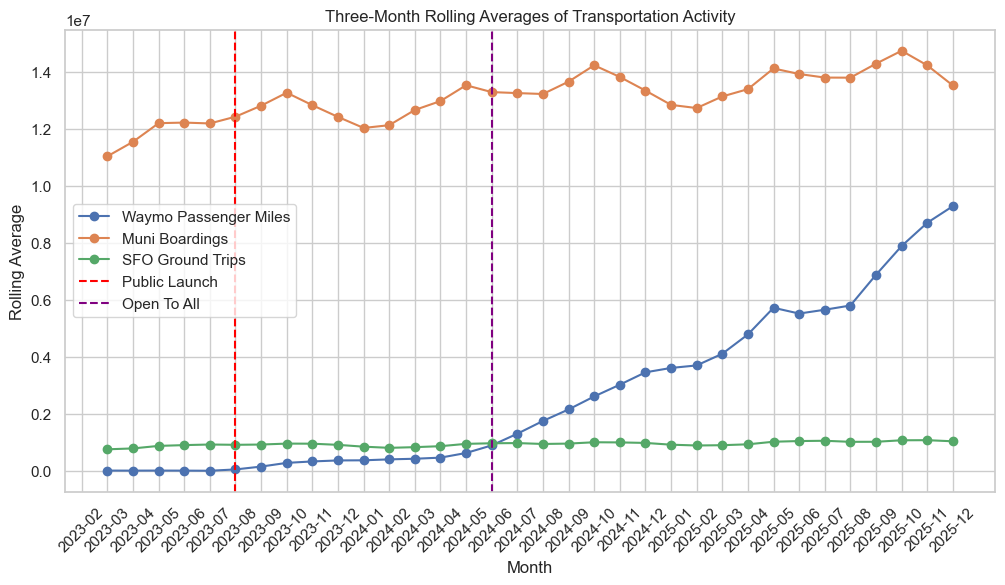

In [9]:
plt.figure(figsize=(12, 6))

plt.plot(
    rolling_df["month"],
    rolling_df["waymo_passenger_miles_rolling_3mo"],
    marker="o",
    label="Waymo Passenger Miles"
)

plt.plot(
    rolling_df["month"],
    rolling_df["muni_monthly_boardings_rolling_3mo"],
    marker="o",
    label="Muni Boardings"
)

plt.plot(
    rolling_df["month"],
    rolling_df["sfo_ground_trips_rolling_3mo"],
    marker="o",
    label="SFO Ground Trips"
)

plt.axvline(
    x="2023-08",
    linestyle="--",
    color="red",
    label="Public Launch"
)

plt.axvline(
    x="2024-06",
    linestyle="--",
    color="purple",
    label="Open To All"
)

plt.title("Three-Month Rolling Averages of Transportation Activity")
plt.ylabel("Rolling Average")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.legend()
plt.show()

## Observation

The three-month rolling averages show that Waymo passenger miles increased sharply over the study period, with the largest growth occurring after the June 2024 open-to-all expansion.

At the same time, Muni boardings and SFO ground transportation activity do not show a clear sustained decline. Muni activity generally remains strong, while SFO ground trips stay relatively stable with smaller fluctuations.

This matters for the final report because it weakens a simple replacement argument. If Waymo were directly reducing demand for other transportation modes, we might expect Muni boardings or SFO ground trips to fall as Waymo usage rose. Instead, the smoothed trends suggest that Waymo’s growth occurred during a broader period of transportation recovery and increasing mobility demand.

# Seasonality Check

This section clarifies why the analysis should control for seasonality.

This section groups the data by calendar month to check whether transportation activity tends to vary depending on the time of year.

Because the dataset only covers 36 months, this is not a full seasonal model. However, it gives an exploratory view of whether month-specific patterns may affect the results.

In [10]:
seasonality_summary = df.groupby("month_num").agg(
    avg_waymo_passenger_miles=("waymo_passenger_miles", "mean"),
    avg_muni_boardings=("muni_monthly_boardings", "mean"),
    avg_sfo_ground_trips=("sfo_ground_trips", "mean"),
    avg_taxi_trips=("taxi_trips", "mean")
).reset_index()

seasonality_summary

,month_num,avg_waymo_passenger_miles,avg_muni_boardings,avg_sfo_ground_trips,avg_taxi_trips
0,1,1.345996e+06,1.210367e+07,8.223920e+05,216242.5
1,2,1.395757e+06,1.174767e+07,7.796240e+05,239945.0
2,3,1.846153e+06,1.303533e+07,9.315573e+05,262887.0
3,4,2.061720e+06,1.318033e+07,9.184217e+05,261453.5
4,5,2.497673e+06,1.368333e+07,1.041006e+06,274017.5
5,6,1.906833e+06,1.262033e+07,1.003346e+06,209284.0
6,7,2.601090e+06,1.299033e+07,9.561930e+05,204971.0
7,8,3.139825e+06,1.388500e+07,9.621193e+05,221375.0
8,9,3.489768e+06,1.393033e+07,1.027539e+06,211829.0
9,10,4.195459e+06,1.447433e+07,1.088919e+06,212373.0


These ratios should be interpreted as relative activity measures rather than literal replacement rates. (For the following plots)

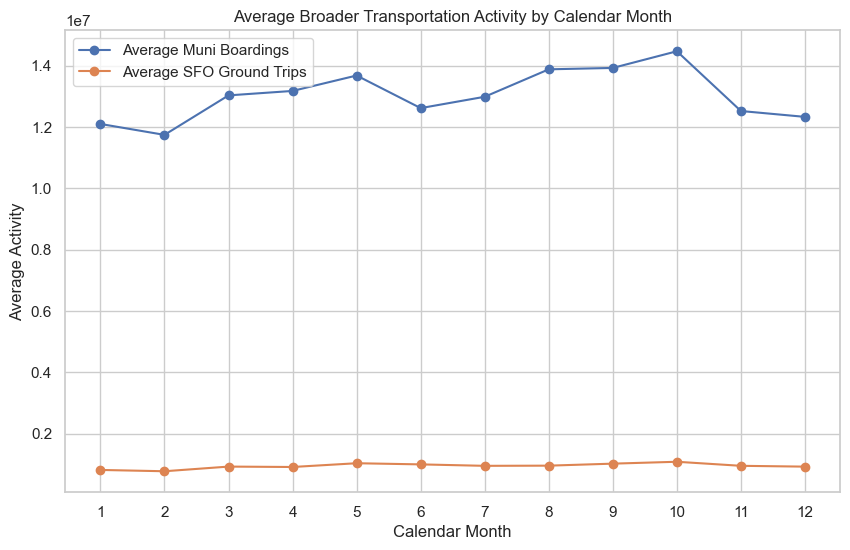

In [11]:
plt.figure(figsize=(10, 6))

plt.plot(
    seasonality_summary["month_num"],
    seasonality_summary["avg_muni_boardings"],
    marker="o",
    label="Average Muni Boardings"
)

plt.plot(
    seasonality_summary["month_num"],
    seasonality_summary["avg_sfo_ground_trips"],
    marker="o",
    label="Average SFO Ground Trips"
)

plt.title("Average Broader Transportation Activity by Calendar Month")
plt.xlabel("Calendar Month")
plt.ylabel("Average Activity")
plt.xticks(range(1, 13))
plt.legend()
plt.show()

## Observation

The seasonality check shows that broader transportation activity varies across calendar months. Muni boardings appear higher during some late-summer and fall months, while SFO ground transportation trips also show smaller month-to-month changes.

This matters because changes around Waymo's launch dates may not be caused by Waymo alone. For example, increases or decreases in Muni boardings and SFO ground trips may partly reflect seasonal travel patterns, school schedules, tourism, or broader demand changes.

Because of this, later regression analysis should include month-based controls or seasonal indicators. This directly responds to why seasonality needs to be considered before making stronger claims about Waymo's relationship with other transportation modes.

# Demand-Adjusted Waymo Measures

Here we account for general transportation trends and confounding factors.

To address this, this section compares Waymo passenger miles relative to broader transportation demand indicators.

Two demand-adjusted measures are created:

1. Waymo passenger miles per SFO ground trip
2. Waymo passenger miles per Muni boarding

These ratios do not prove causation, but they help show whether Waymo activity was growing faster than broader travel activity.

In [12]:
df["waymo_per_sfo_trip"] = df["waymo_passenger_miles"] / df["sfo_ground_trips"]
df["waymo_per_muni_boarding"] = df["waymo_passenger_miles"] / df["muni_monthly_boardings"]

df[
    [
        "month",
        "waymo_per_sfo_trip",
        "waymo_per_muni_boarding"
    ]
].head()

,month,waymo_per_sfo_trip,waymo_per_muni_boarding
0,2023-01,0.040167,0.002843
1,2023-02,0.029488,0.001925
2,2023-03,0.026476,0.001931
3,2023-04,0.030613,0.002128
4,2023-05,0.027273,0.002080


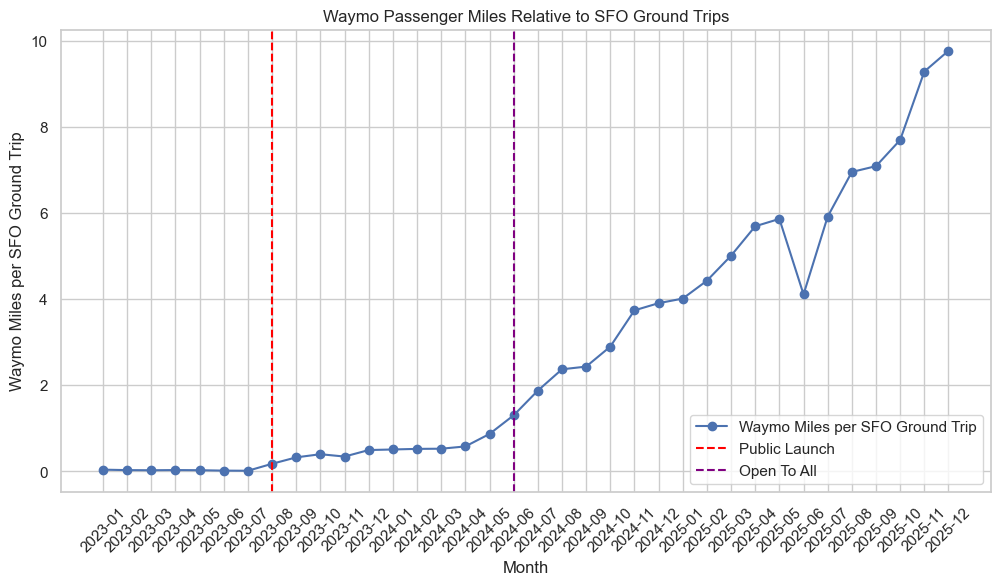

In [13]:
plt.figure(figsize=(12, 6))

plt.plot(
    df["month"],
    df["waymo_per_sfo_trip"],
    marker="o",
    label="Waymo Miles per SFO Ground Trip"
)

plt.axvline(
    x="2023-08",
    linestyle="--",
    color="red",
    label="Public Launch"
)

plt.axvline(
    x="2024-06",
    linestyle="--",
    color="purple",
    label="Open To All"
)

plt.title("Waymo Passenger Miles Relative to SFO Ground Trips")
plt.ylabel("Waymo Miles per SFO Ground Trip")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.legend()
plt.show()

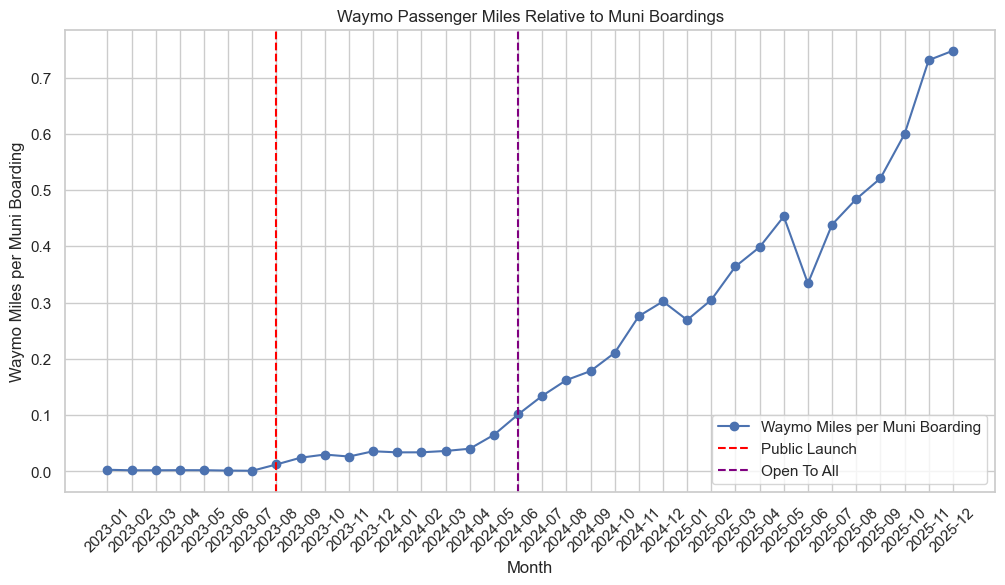

In [14]:
plt.figure(figsize=(12, 6))

plt.plot(
    df["month"],
    df["waymo_per_muni_boarding"],
    marker="o",
    label="Waymo Miles per Muni Boarding"
)

plt.axvline(
    x="2023-08",
    linestyle="--",
    color="red",
    label="Public Launch"
)

plt.axvline(
    x="2024-06",
    linestyle="--",
    color="purple",
    label="Open To All"
)

plt.title("Waymo Passenger Miles Relative to Muni Boardings")
plt.ylabel("Waymo Miles per Muni Boarding")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.legend()
plt.show()

## Observation

The demand-adjusted measures increase steadily over time, showing that Waymo passenger miles grew faster than both SFO ground trips and Muni boardings.

This does not mean that Waymo directly replaced either transportation mode. Instead, it suggests that Waymo became a larger part of the local transportation environment during the study period, even after accounting for broader travel demand indicators.

This is useful for the comprehensive report because it gives a more careful interpretation than raw Waymo growth alone. Waymo growth remained strong relative to other transportation activity, but this still does not prove that Waymo caused declines in other modes.

# Exploratory Regression Check With Controls

Here we clarify how the analysis accounts for time trends, seasonality, and broader transportation demand.

To address this, this section runs a small exploratory regression check. The goal is not to make a strong causal claim, but to see whether the relationship between Waymo activity and other transportation outcomes changes after adding basic controls.

The models use Muni monthly boardings as the outcome because Muni data are available for the full study period from January 2023 to December 2025.

The models compare:

1. A simple model with Waymo passenger miles only
2. A model adding time trend
3. A model adding time trend and SFO ground trips
4. A model adding time trend, SFO ground trips, and calendar-month controls for seasonality

In [20]:
import statsmodels.formula.api as smf


model_1 = smf.ols(
    "muni_monthly_boardings ~ waymo_passenger_miles",
    data=df
).fit()

model_2 = smf.ols(
    "muni_monthly_boardings ~ waymo_passenger_miles + time_trend",
    data=df
).fit()

model_3 = smf.ols(
    "muni_monthly_boardings ~ waymo_passenger_miles + time_trend + sfo_ground_trips",
    data=df
).fit()

model_4 = smf.ols(
    "muni_monthly_boardings ~ waymo_passenger_miles + time_trend + sfo_ground_trips + C(month_num)",
    data=df
).fit()

In [21]:
regression_table = pd.DataFrame({
    "Model": [
        "Model 1: Waymo only",
        "Model 2: + Time trend",
        "Model 3: + SFO demand control",
        "Model 4: + Month controls"
    ],
    "Waymo Coefficient": [
        model_1.params["waymo_passenger_miles"],
        model_2.params["waymo_passenger_miles"],
        model_3.params["waymo_passenger_miles"],
        model_4.params["waymo_passenger_miles"]
    ],
    "Waymo P-Value": [
        model_1.pvalues["waymo_passenger_miles"],
        model_2.pvalues["waymo_passenger_miles"],
        model_3.pvalues["waymo_passenger_miles"],
        model_4.pvalues["waymo_passenger_miles"]
    ],
    "R-Squared": [
        model_1.rsquared,
        model_2.rsquared,
        model_3.rsquared,
        model_4.rsquared
    ],
    "Adj. R-Squared": [
        model_1.rsquared_adj,
        model_2.rsquared_adj,
        model_3.rsquared_adj,
        model_4.rsquared_adj
    ]
})

regression_table

,Model,Waymo Coefficient,Waymo P-Value,R-Squared,Adj. R-Squared
0,Model 1: Waymo only,0.199419,0.000327,0.319656,0.299646
1,Model 2: + Time trend,-0.143360,0.236352,0.473897,0.442012
2,Model 3: + SFO demand control,-0.148394,0.067815,0.777467,0.756605
3,Model 4: + Month controls,-0.180944,0.000035,0.974136,0.956893


## Observation

The exploratory regression table shows how the estimated relationship between Waymo passenger miles and Muni boardings changes after adding controls.

In the simple model, the Waymo coefficient is positive, suggesting that Waymo passenger miles and Muni boardings increased together over the study period. However, after adding a time trend, SFO ground trips, and calendar-month controls, the Waymo coefficient becomes negative. This suggests that the simple relationship was partly influenced by broader transportation growth, time trends, and seasonal patterns.

This is important because it shows why a simple correlation is not enough to evaluate Waymo's relationship with Muni ridership. Once controls are added, the estimated relationship changes, meaning the analysis needs to account for confounding factors before making stronger claims.

These results should still be interpreted carefully because the dataset only contains 36 monthly observations, and the model with month controls includes many predictors for a small sample. Therefore, this regression should be treated as exploratory rather than causal evidence.

# EDA Summary

The event-window analysis compared transportation activity before and after Waymo’s August 2023 public launch and June 2024 open-to-all expansion. Waymo passenger miles increased around these expansion periods, but the changes should be interpreted carefully because other transportation indicators were also changing during the same months. Taxi data are also limited because they only extend through May 2024, so the dataset cannot evaluate taxi activity after the June 2024 expansion.

The rolling average analysis smoothed month-to-month variation and showed that Waymo passenger miles followed a strong upward trend, especially after June 2024. However, Muni boardings and SFO ground transportation activity did not show a clear sustained decline during the same period. This suggests that Waymo growth may have occurred alongside broader transportation activity rather than directly replacing other modes.

The seasonality check showed that transportation activity varies by calendar month. This means some changes around Waymo’s expansion dates may reflect normal seasonal travel patterns instead of Waymo expansion alone. Because of this, future regression analysis should include month or seasonal controls.

The demand-adjusted Waymo measures compared Waymo passenger miles relative to Muni boardings and SFO ground trips. These ratios increased over time, suggesting that Waymo became a larger part of the transportation market. However, this does not prove that Waymo caused decreases in other transportation modes.

The exploratory regression check compared a simple Waymo-only model with models that added time trend, SFO ground trips, and calendar-month controls. This helped show why simple correlations are limited. If the Waymo coefficient changes after controls are added, then the relationship may be partly explained by broader trends, general travel demand, or seasonality.

Overall, this additional EDA suggests that Waymo expanded rapidly, but the evidence does not clearly show that it immediately reduced taxi activity or public transit ridership. The main takeaway is that Waymo growth happened during a period of broader transportation change, so the final report should be cautious and account for time trends, seasonality, and general travel demand.